In [2]:
# ═══════════════════════════════════════════════════════
# CELL 1: INSTALLS
# ═══════════════════════════════════════════════════════
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn tqdm --quiet
print("✅ All packages installed.")

✅ All packages installed.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# ═══════════════════════════════════════════════════════
# CELL 2: IMPORTS & CONFIG
# ═══════════════════════════════════════════════════════
import os, pickle, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

FS_OUTPUT_FOLDER = '/content/drive/MyDrive/final_dataset/fs'

SUPERCLASSES = ['Benign', 'DDoS', 'Web-based', 'Recon', 'DoS', 'Mirai', 'Spoofing', 'Brute Force']

print("✅ Imports done.")

✅ Imports done.


In [5]:
# ═══════════════════════════════════════════════════════
# CELL 3: MOUNT DRIVE & LOAD ALL RESULTS
# ═══════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

def load_pkl(name):
    path = os.path.join(FS_OUTPUT_FOLDER, name)
    with open(path, 'rb') as f:
        return pickle.load(f)

ffs_data = load_pkl('ffs_results.pkl')
bfe_data = load_pkl('bfe_results.pkl')
rfe_data = load_pkl('rfe_results.pkl')

# ── Unpack ────────────────────────────────────────────────────────────────────
ffs_result       = ffs_data['ffs_result']
ffs_history      = ffs_data['ffs_history']
ffs_opt_k        = ffs_data['ffs_opt_k']
ffs_opt_acc      = ffs_data['ffs_opt_acc']
ffs_opt_features = ffs_data['ffs_opt_features']

bfe_result     = bfe_data['bfe_result']
bfe_history    = bfe_data['bfe_history']
bfe_opt_k      = bfe_data['bfe_opt_k']
bfe_opt_acc    = bfe_data['bfe_opt_acc']
bfe_opt_feats  = bfe_data['bfe_opt_feats']

rfe_result    = rfe_data['rfe_result']
rfe_sweep     = rfe_data['rfe_sweep']
rfe_opt_k     = rfe_data['rfe_opt_k']
rfe_opt_acc   = rfe_data['rfe_opt_acc']
rfe_opt_feats = rfe_data['rfe_opt_feats']
rfe_ranking   = rfe_data['rfe_ranking']

# baseline_result is identical across all 3 pkl files (same data, same seed)
baseline_result = ffs_data['baseline_result']
ALL_FEATURES    = ffs_data['ALL_FEATURES']

METHODS = [
    ('Baseline (All 15)', baseline_result),
    ('FFS',  ffs_result),
    ('BFE',  bfe_result),
    ('RFE',  rfe_result),
]

print("✅ All results loaded successfully.")
print(f"   FFS: k={ffs_opt_k}, acc={ffs_opt_acc:.4f}%")
print(f"   BFE: k={bfe_opt_k}, acc={bfe_opt_acc:.4f}%")
print(f"   RFE: k={rfe_opt_k}, acc={rfe_opt_acc:.4f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All results loaded successfully.
   FFS: k=13, acc=93.1274%
   BFE: k=13, acc=93.1172%
   RFE: k=14, acc=93.0923%


In [6]:
# ═══════════════════════════════════════════════════════
# CELL 4: DETAILED PER-METHOD SUMMARY  (PPT-ready)
#   For each method: print the full table like your
#   baseline screenshot. Also shows delta vs baseline.
# ═══════════════════════════════════════════════════════

def print_detail_block(label, result, compare_to=None):
    n = result['n_features']
    acc = result['accuracy']
    feats = result['features']
    pc = result['per_class']

    print()
    print("╔" + "═"*68 + "╗")
    print(f"║  📊  {label:<62}║")
    print(f"║  Features used ({n}): {str(feats)[:50]:<50}  ║")
    print("╠" + "═"*68 + "╣")
    print(f"  {'Superclass':<14} {'Samples':>9} {'Detection %':>12} {'Missed':>8}", end="")
    if compare_to:
        print(f"  {'Δ Detection':>12}", end="")
    print()
    print("  " + "-"*60)

    for sc in SUPERCLASSES:
        if sc not in pc:
            continue
        m = pc[sc]
        line = f"  {sc:<14} {m['samples']:>9,} {m['detection_rate']:>11.2f}% {m['missed']:>8,}"
        if compare_to and sc in compare_to['per_class']:
            base_dr = compare_to['per_class'][sc]['detection_rate']
            delta   = m['detection_rate'] - base_dr
            arrow   = "▲" if delta > 0.01 else ("▼" if delta < -0.01 else "─")
            line   += f"  {arrow} {delta:+.2f}%"
        print(line)

    print("  " + "-"*60)
    if compare_to:
        acc_delta = acc - compare_to['accuracy']
        arrow = "▲" if acc_delta > 0.001 else ("▼" if acc_delta < -0.001 else "─")
        print(f"  ⚡ Total Inference Time  : {result['inference_time']}s")
        print(f"  🚀 Throughput            : {result['throughput']:,} samples/sec")
        print(f"  🎯 Accuracy              : {acc}%   {arrow} {acc_delta:+.4f}% vs baseline")
    else:
        print(f"  ⚡ Total Inference Time  : {result['inference_time']}s")
        print(f"  🚀 Throughput            : {result['throughput']:,} samples/sec")
        print(f"  🎯 Accuracy              : {acc}%")
    print("╚" + "═"*68 + "╝")


for name, result in METHODS:
    if name == 'Baseline (All 15)':
        print_detail_block(name, result, compare_to=None)
    else:
        print_detail_block(name, result, compare_to=baseline_result)


╔════════════════════════════════════════════════════════════════════╗
║  📊  Baseline (All 15)                                             ║
║  Features used (15): ['number', 'https', 'ack_flag_number', 'time_to_li  ║
╠════════════════════════════════════════════════════════════════════╣
  Superclass       Samples  Detection %   Missed
  ------------------------------------------------------------
  Benign           205,326       96.06%    8,080
  DDoS              87,976      100.00%        2
  Web-based         48,056       94.03%    2,871
  Recon             40,058       62.08%   15,189
  DoS               31,778      100.00%        0
  Mirai             24,110      100.00%        0
  Spoofing          15,898       73.45%    4,221
  Brute Force        8,124       80.51%    1,583
  ------------------------------------------------------------
  ⚡ Total Inference Time  : 28.2209s
  🚀 Throughput            : 16,347 samples/sec
  🎯 Accuracy              : 93.0752%
╚═════════════════════

In [7]:
# ═══════════════════════════════════════════════════════
# CELL 5: SUMMARY COMPARISON TABLE  (all methods side-by-side)
# ═══════════════════════════════════════════════════════

print("\n" + "="*90)
print(f"  {'METHOD COMPARISON SUMMARY':^86}")
print("="*90)
print(f"  {'Superclass':<15}", end="")
for name, r in METHODS:
    short = name.replace('Baseline (All 15)', 'Baseline').replace(' features)',')')
    print(f" {short:>18}", end="")
print()
print("-"*90)

for sc in SUPERCLASSES:
    print(f"  {sc:<15}", end="")
    for name, r in METHODS:
        dr = r['per_class'].get(sc, {}).get('detection_rate', 0)
        print(f" {dr:>17.2f}%", end="")
    print()

print("-"*90)
print(f"  {'OVERALL ACC':<15}", end="")
for name, r in METHODS:
    print(f" {r['accuracy']:>17.4f}%", end="")
print()
print(f"  {'# Features':<15}", end="")
for name, r in METHODS:
    print(f" {r['n_features']:>18}", end="")
print()
print("="*90)

# ── Winners per class ─────────────────────────────────────────────────────────
print("\n  🏆 BEST METHOD PER SUPERCLASS:")
print("  " + "-"*50)
for sc in SUPERCLASSES:
    scores = [(name, r['per_class'].get(sc, {}).get('detection_rate', 0)) for name, r in METHODS]
    winner = max(scores, key=lambda x: x[1])
    base_dr = baseline_result['per_class'].get(sc, {}).get('detection_rate', 0)
    delta = winner[1] - base_dr
    tag = f"  ▲ +{delta:.2f}% vs baseline" if delta > 0.01 else ("  (tied/same)" if abs(delta) < 0.01 else f"  ▼ {delta:.2f}% vs baseline")
    print(f"  {sc:<14}: {winner[0]:<25} {winner[1]:.2f}%{tag}")
print()


                                METHOD COMPARISON SUMMARY                               
  Superclass                Baseline                FFS                BFE                RFE
------------------------------------------------------------------------------------------
  Benign                      96.06%             96.15%             96.13%             96.10%
  DDoS                       100.00%            100.00%            100.00%            100.00%
  Web-based                   94.03%             94.07%             94.03%             94.10%
  Recon                       62.08%             62.09%             62.13%             62.07%
  DoS                        100.00%            100.00%            100.00%            100.00%
  Mirai                      100.00%            100.00%            100.00%            100.00%
  Spoofing                    73.45%             73.68%             73.65%             73.29%
  Brute Force                 80.51%             80.64%            

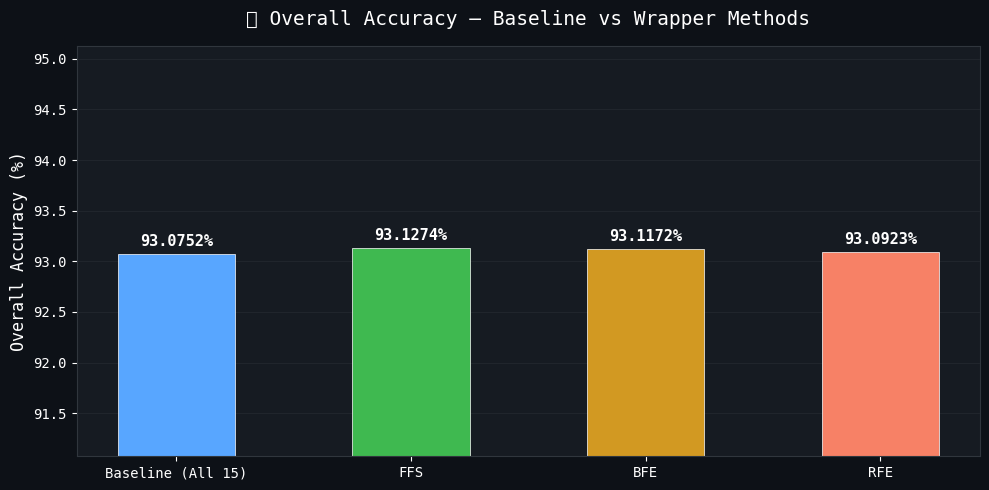

  ✅ Saved: plot1_overall_accuracy.png


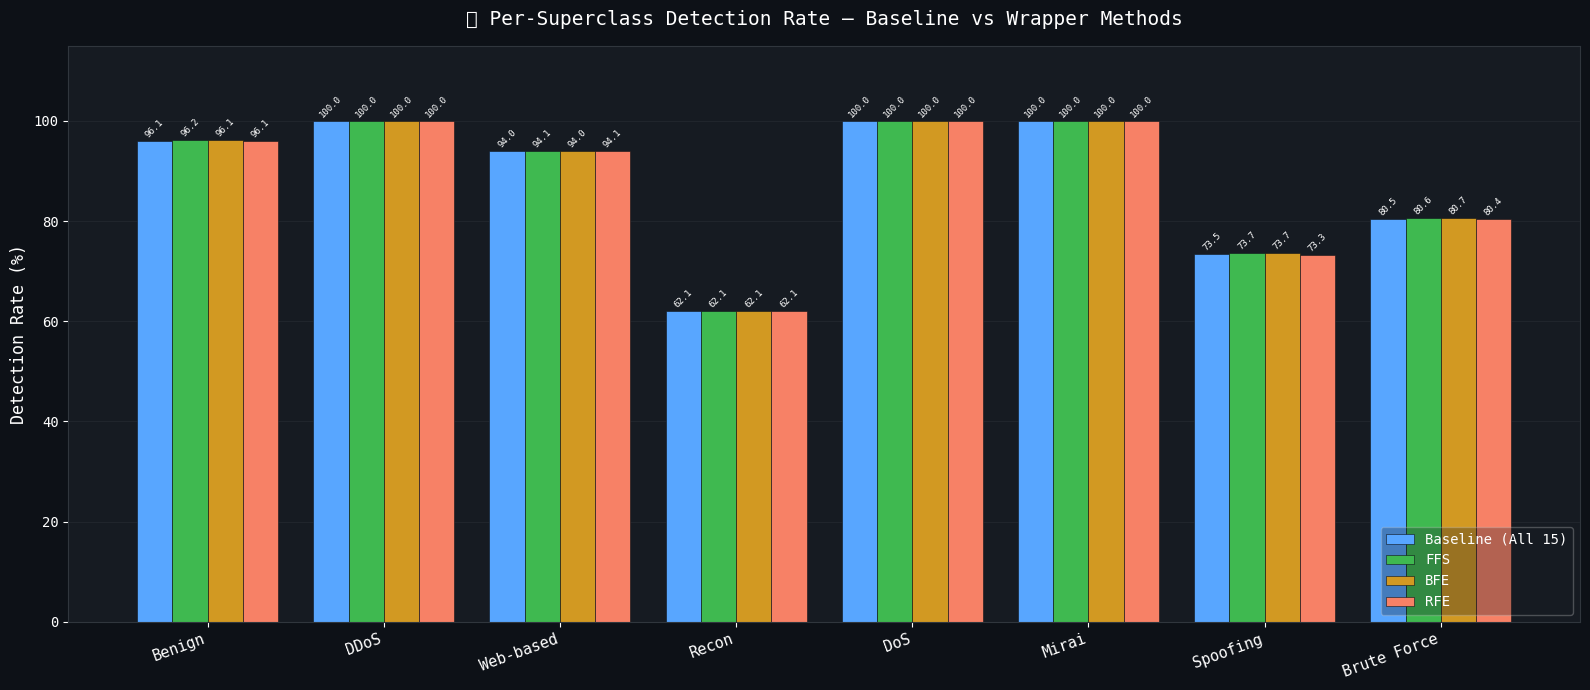

  ✅ Saved: plot2_per_class_detection.png


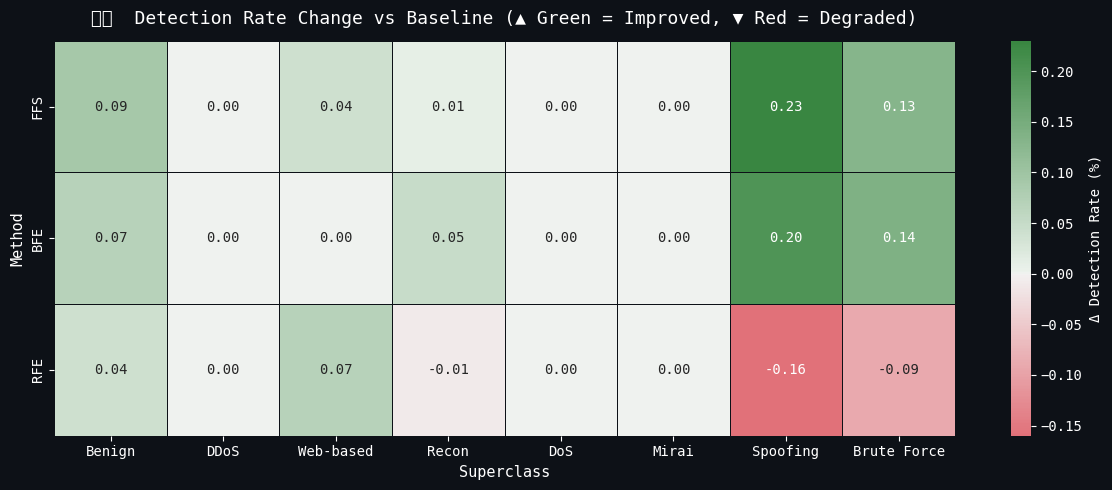

  ✅ Saved: plot3_delta_heatmap.png


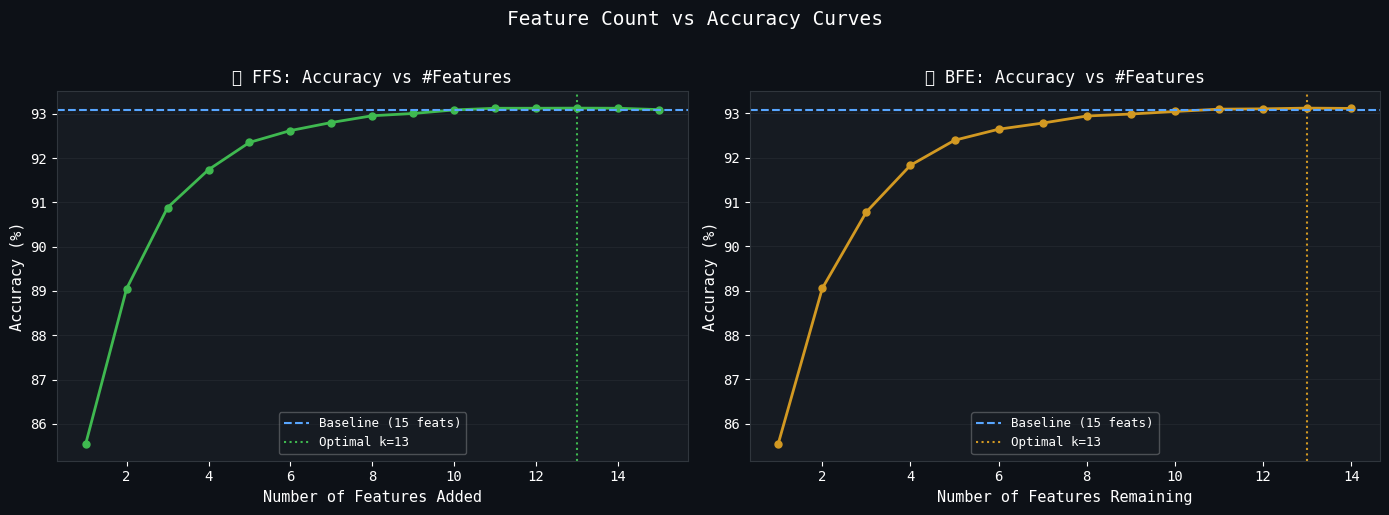

  ✅ Saved: plot4_selection_curves.png


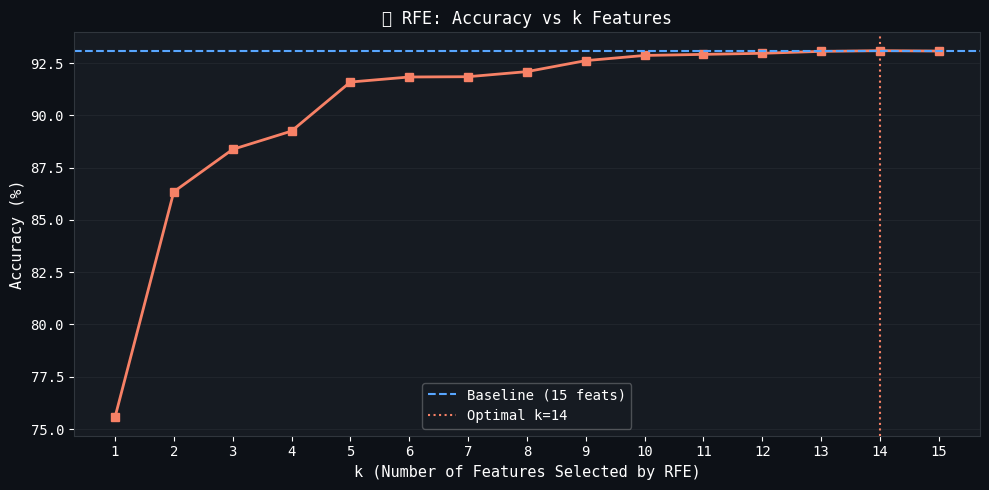

  ✅ Saved: plot5_rfe_sweep.png


In [8]:
# ═══════════════════════════════════════════════════════
# CELL 6: VISUALIZATIONS  (PPT-ready plots)
# ═══════════════════════════════════════════════════════
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#30363d',
    'font.family':      'monospace',
})

COLORS = {
    'Baseline (All 15)': '#58a6ff',
    'FFS':               '#3fb950',
    'BFE':               '#d29922',
    'RFE':               '#f78166',
}

# ── Plot 1: Overall Accuracy Comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
names   = [m[0] for m in METHODS]
accs    = [m[1]['accuracy'] for m in METHODS]
colors  = [COLORS[n] for n in names]

bars = ax.bar(names, accs, color=colors, width=0.5, edgecolor='white', linewidth=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{acc:.4f}%', ha='center', va='bottom', fontsize=11, color='white', fontweight='bold')

ax.set_ylim(min(accs) - 2, max(accs) + 2)
ax.set_ylabel('Overall Accuracy (%)', fontsize=12)
ax.set_title('📊 Overall Accuracy — Baseline vs Wrapper Methods', fontsize=14, pad=15)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('/content/plot1_overall_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Saved: plot1_overall_accuracy.png")

# ── Plot 2: Per-Superclass Detection Rate — Grouped Bar ──────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
x   = np.arange(len(SUPERCLASSES))
w   = 0.2
off = [-1.5, -0.5, 0.5, 1.5]

for i, (name, result) in enumerate(METHODS):
    drs = [result['per_class'].get(sc, {}).get('detection_rate', 0) for sc in SUPERCLASSES]
    b   = ax.bar(x + off[i]*w, drs, width=w, label=name, color=COLORS[name],
                 edgecolor='#0d1117', linewidth=0.4)
    for bar, v in zip(b, drs):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=6.5, color='white', rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(SUPERCLASSES, rotation=20, ha='right', fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel('Detection Rate (%)', fontsize=12)
ax.set_title('🔍 Per-Superclass Detection Rate — Baseline vs Wrapper Methods', fontsize=14, pad=15)
ax.legend(loc='lower right', fontsize=10, framealpha=0.3)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('/content/plot2_per_class_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Saved: plot2_per_class_detection.png")

# ── Plot 3: Delta vs Baseline (heatmap style) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
method_names = ['FFS', 'BFE', 'RFE']
method_results_only = [ffs_result, bfe_result, rfe_result]
delta_matrix = []
for r in method_results_only:
    row = []
    for sc in SUPERCLASSES:
        base_dr = baseline_result['per_class'].get(sc, {}).get('detection_rate', 0)
        curr_dr = r['per_class'].get(sc, {}).get('detection_rate', 0)
        row.append(round(curr_dr - base_dr, 2))
    delta_matrix.append(row)

delta_df = pd.DataFrame(delta_matrix, index=method_names, columns=SUPERCLASSES)
cmap = sns.diverging_palette(10, 130, as_cmap=True)
sns.heatmap(delta_df, annot=True, fmt='.2f', cmap=cmap, center=0,
            linewidths=0.5, linecolor='#0d1117',
            cbar_kws={'label': 'Δ Detection Rate (%)'},
            ax=ax)
ax.set_title('🌡️  Detection Rate Change vs Baseline (▲ Green = Improved, ▼ Red = Degraded)',
             fontsize=13, pad=12)
ax.set_xlabel('Superclass', fontsize=11)
ax.set_ylabel('Method', fontsize=11)
plt.tight_layout()
plt.savefig('/content/plot3_delta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Saved: plot3_delta_heatmap.png")

# ── Plot 4: FFS/BFE accuracy curve over steps ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# FFS curve
ffs_ks   = [h[0] for h in ffs_history]
ffs_accs = [h[1] for h in ffs_history]
ax1.plot(ffs_ks, ffs_accs, color='#3fb950', marker='o', markersize=5, linewidth=2)
ax1.axhline(baseline_result['accuracy'], color='#58a6ff', linestyle='--', linewidth=1.5, label='Baseline (15 feats)')
ax1.axvline(ffs_opt_k, color='#3fb950', linestyle=':', linewidth=1.5, label=f'Optimal k={ffs_opt_k}')
ax1.set_xlabel('Number of Features Added', fontsize=11)
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_title('📈 FFS: Accuracy vs #Features', fontsize=12)
ax1.legend(fontsize=9, framealpha=0.3)
ax1.yaxis.grid(True, alpha=0.4)
ax1.set_axisbelow(True)

# BFE curve
bfe_ks   = [h[0] for h in bfe_history]
bfe_accs = [h[1] for h in bfe_history]
ax2.plot(bfe_ks, bfe_accs, color='#d29922', marker='o', markersize=5, linewidth=2)
ax2.axhline(baseline_result['accuracy'], color='#58a6ff', linestyle='--', linewidth=1.5, label='Baseline (15 feats)')
ax2.axvline(bfe_opt_k, color='#d29922', linestyle=':', linewidth=1.5, label=f'Optimal k={bfe_opt_k}')
ax2.set_xlabel('Number of Features Remaining', fontsize=11)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_title('📉 BFE: Accuracy vs #Features', fontsize=12)
ax2.legend(fontsize=9, framealpha=0.3)
ax2.yaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)

plt.suptitle('Feature Count vs Accuracy Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/content/plot4_selection_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Saved: plot4_selection_curves.png")

# ── Plot 5: RFE k sweep ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
rfe_ks   = [s[0] for s in rfe_sweep]
rfe_accs = [s[1] for s in rfe_sweep]
ax.plot(rfe_ks, rfe_accs, color='#f78166', marker='s', markersize=6, linewidth=2)
ax.axhline(baseline_result['accuracy'], color='#58a6ff', linestyle='--', linewidth=1.5, label='Baseline (15 feats)')
ax.axvline(rfe_opt_k, color='#f78166', linestyle=':', linewidth=1.5, label=f'Optimal k={rfe_opt_k}')
ax.set_xlabel('k (Number of Features Selected by RFE)', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('📊 RFE: Accuracy vs k Features', fontsize=12)
ax.legend(fontsize=10, framealpha=0.3)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
ax.set_xticks(rfe_ks)
plt.tight_layout()
plt.savefig('/content/plot5_rfe_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Saved: plot5_rfe_sweep.png")

In [9]:
# ═══════════════════════════════════════════════════════
# CELL 7: FEATURE AGREEMENT — Which features were
#          selected by which methods?
# ═══════════════════════════════════════════════════════
print("\n" + "="*72)
print(f"  {'FEATURE SELECTION AGREEMENT TABLE':^68}")
print("="*72)
print(f"  {'Feature':<30} {'FFS':>6} {'BFE':>6} {'RFE':>6} {'Votes':>7}")
print("-"*72)

agreement = []
for feat in ALL_FEATURES:
    in_ffs = "✅" if feat in ffs_opt_features else "❌"
    in_bfe = "✅" if feat in bfe_opt_feats    else "❌"
    in_rfe = "✅" if feat in rfe_opt_feats    else "❌"
    votes  = sum([feat in ffs_opt_features, feat in bfe_opt_feats, feat in rfe_opt_feats])
    agreement.append((feat, in_ffs, in_bfe, in_rfe, votes))

# Sort by votes desc
agreement.sort(key=lambda x: -x[4])
for row in agreement:
    print(f"  {row[0]:<30} {row[1]:>6} {row[2]:>6} {row[3]:>6} {row[4]:>7}/3")

print("="*72)
print()
consensus = [r[0] for r in agreement if r[4] == 3]
print(f"  🤝 Consensus Features (selected by ALL 3 methods): {len(consensus)}")
for f in consensus:
    print(f"     • {f}")


                   FEATURE SELECTION AGREEMENT TABLE                  
  Feature                           FFS    BFE    RFE   Votes
------------------------------------------------------------------------
  https                               ✅      ✅      ✅       3/3
  time_to_live                        ✅      ✅      ✅       3/3
  psh_flag_number                     ✅      ✅      ✅       3/3
  header_length                       ✅      ✅      ✅       3/3
  iat                                 ✅      ✅      ✅       3/3
  tot sum                             ✅      ✅      ✅       3/3
  rate                                ✅      ✅      ✅       3/3
  max                                 ✅      ✅      ✅       3/3
  syn_flag_number                     ✅      ✅      ✅       3/3
  variance                            ✅      ✅      ✅       3/3
  udp                                 ✅      ✅      ✅       3/3
  ack_flag_number                     ✅      ❌      ✅       2/3
  ack_count              

In [10]:
# ═══════════════════════════════════════════════════════
# CELL 8: FINAL TAKEAWAYS — Clean PPT-ready summary
# ═══════════════════════════════════════════════════════
print()
print("╔" + "═"*72 + "╗")
print(f"║  {'🏁  FINAL RESULTS SUMMARY':^70}  ║")
print("╠" + "═"*72 + "╣")

best_method = max(METHODS, key=lambda x: x[1]['accuracy'])
worst_class = {}
best_class  = {}

for name, r in METHODS:
    for sc, m in r['per_class'].items():
        if sc not in worst_class or m['detection_rate'] < worst_class[sc][1]:
            worst_class[sc] = (name, m['detection_rate'])
        if sc not in best_class or m['detection_rate'] > best_class[sc][1]:
            best_class[sc] = (name, m['detection_rate'])

print(f"║  Best overall method      : {best_method[0]:<20} ({best_method[1]['accuracy']:.4f}%){'':>6}║")

# Classes that improved vs baseline
improved = []
degraded = []
for sc in SUPERCLASSES:
    base_dr = baseline_result['per_class'].get(sc, {}).get('detection_rate', 0)
    best_dr = max(r['per_class'].get(sc, {}).get('detection_rate', 0) for _, r in METHODS[1:])
    delta   = best_dr - base_dr
    if delta > 0.1:
        improved.append((sc, delta))
    elif delta < -0.1:
        degraded.append((sc, delta))

print("╠" + "═"*72 + "╣")
print(f"║  {'CLASSES WHERE WRAPPER METHODS HELPED (vs baseline)':^70}  ║")
if improved:
    for sc, d in sorted(improved, key=lambda x: -x[1]):
        print(f"║    ▲ {sc:<14} improved by up to {d:+.2f}%{'':>22}║")
else:
    print(f"║    (No significant improvement found){'':>34}║")

print("╠" + "═"*72 + "╣")
print(f"║  {'CLASSES WHERE WRAPPER METHODS HURT (vs baseline)':^70}  ║")
if degraded:
    for sc, d in sorted(degraded, key=lambda x: x[1]):
        print(f"║    ▼ {sc:<14} degraded by      {d:+.2f}%{'':>22}║")
else:
    print(f"║    (No significant degradation found — all methods competitive){'':>8}║")

print("╠" + "═"*72 + "╣")
print(f"║  {'RECOMMENDATION':^70}  ║")
print("╠" + "═"*72 + "╣")
all_accs = [(n, r['accuracy'], r['n_features']) for n, r in METHODS]
print(f"║  Method     Accuracy     #Features    vs Baseline{'':>21}║")
print(f"║  " + "-"*68 + "  ║")
for name, acc, nf in all_accs:
    delta = acc - baseline_result['accuracy']
    arrow = "▲" if delta > 0.001 else ("▼" if delta < -0.001 else "─")
    print(f"║  {name:<12} {acc:.4f}%   {nf:>9}     {arrow} {delta:+.4f}%{'':>18}║")
print("╚" + "═"*72 + "╝")


╔════════════════════════════════════════════════════════════════════════╗
║                         🏁  FINAL RESULTS SUMMARY                         ║
╠════════════════════════════════════════════════════════════════════════╣
║  Best overall method      : FFS                  (93.1274%)      ║
╠════════════════════════════════════════════════════════════════════════╣
║            CLASSES WHERE WRAPPER METHODS HELPED (vs baseline)            ║
║    ▲ Spoofing       improved by up to +0.23%                      ║
║    ▲ Brute Force    improved by up to +0.14%                      ║
╠════════════════════════════════════════════════════════════════════════╣
║             CLASSES WHERE WRAPPER METHODS HURT (vs baseline)             ║
║    (No significant degradation found — all methods competitive)        ║
╠════════════════════════════════════════════════════════════════════════╣
║                              RECOMMENDATION                              ║
╠═══════════════════════════════